<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS2 - Modelizando un ADC*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Introducción teórica**</u>

Un conversor analogico - digital (ADC) actúa como un puente entre el mundo analógico, caracterizado por señales continuas en el tiempo, y el mundo digital, basado en secuencias discretas de valores binarios. Para que los sistemas digitales puedan procesar señales analógicas, es necesario convertir dichas señales a formato digital de manera precisa y consistente. 

El proceso de converción llevado a cabo por un ADC involucra principalmente dos etapas: 

- Muestreo: consiste en tomar valores de la señal analógica en instantes discretos de tiempo, determinados por la frecuencia de muestreo ($f_{s}$).
- Cuantización: implica discretizar los valores de amplitud de la señal, asignando cada muestra al nivel más cercano dentro de un conjunto finito de valores definidos por la resoluión de *B* bits.

La cuantización introduce una pérdida irreversible de información. Este error se manifiesta como ruido de cuantizacion, el cual se modela como una señal aleatoria de media nula ($\mu = 0$). 

La potencia de este ruido esta dada por:
$$P_{q} = \frac{q^2}{12}$$
donde $q = \frac{2 \cdot V_{cc}}{2^B} = \frac{V_{cc}}{2^{B - 1}}$ es el paso de cuantización, el cual esta determinado por el rango analogico del ADC ($+-V_{F}$, define los límites máximos y mínimos de la señal que puede representarse sin saturación) y la cantidad de bits *B*, que fija el número de niveles disponibles $2^B$.

En este trabajo, la se;al de entrada $s_{R}$ es de caracter aditivo: $s_{R} = s + n$

- La se;al (*s*): es una senoidal con energia normalizada (varianza unitaria, $P_{s} = 1$) y frecuencia $f_{0}$.
- El ruido aditivo (*n*): representa la interferencia externa antes de la cuantizacion. Se define como un proceso Gaussiano e incorrelado (ruido blanco), lo que significa que ss muestras son independientes entre si y su densidad de probabilidad sigue una campana de Gauss de media nula. Su potencia sera $P_{n} = k_{n} \cdot P_{q}$ siendo $k_{n}$ una escala.

La combinacion de estos factores define el piso de ruido del sistema. El ruido total presente en la se;al digitalizada sera la suma de la interferencia externa (*n*) y el error propio de cuantizacion (*q*). Este piso de ruido limita la capacidad de detectar se;ales de baja amplitud, ya que cualquier componente por debajo de este nivel queda *"tapado"* por el ruido.

Finalmente, la precision real del sistema puede evaluarse mediante el ENOB (Effective Number of Bits). Este parametro permite comparar el rendimiento del ADC real (afectado por el ruido aditivo *n* y la cunatizacion) con un ADC ideal, determinando cuantos bits de resolucion son efectivamente aprovechables ante la presencia de distorsiones y ruido. A mayor cantidad de bits, mayor cantidad de niveles de cuantización y mejor representación de la señal. 

# <u>**Análisis y desarrollo**</u>

a) 

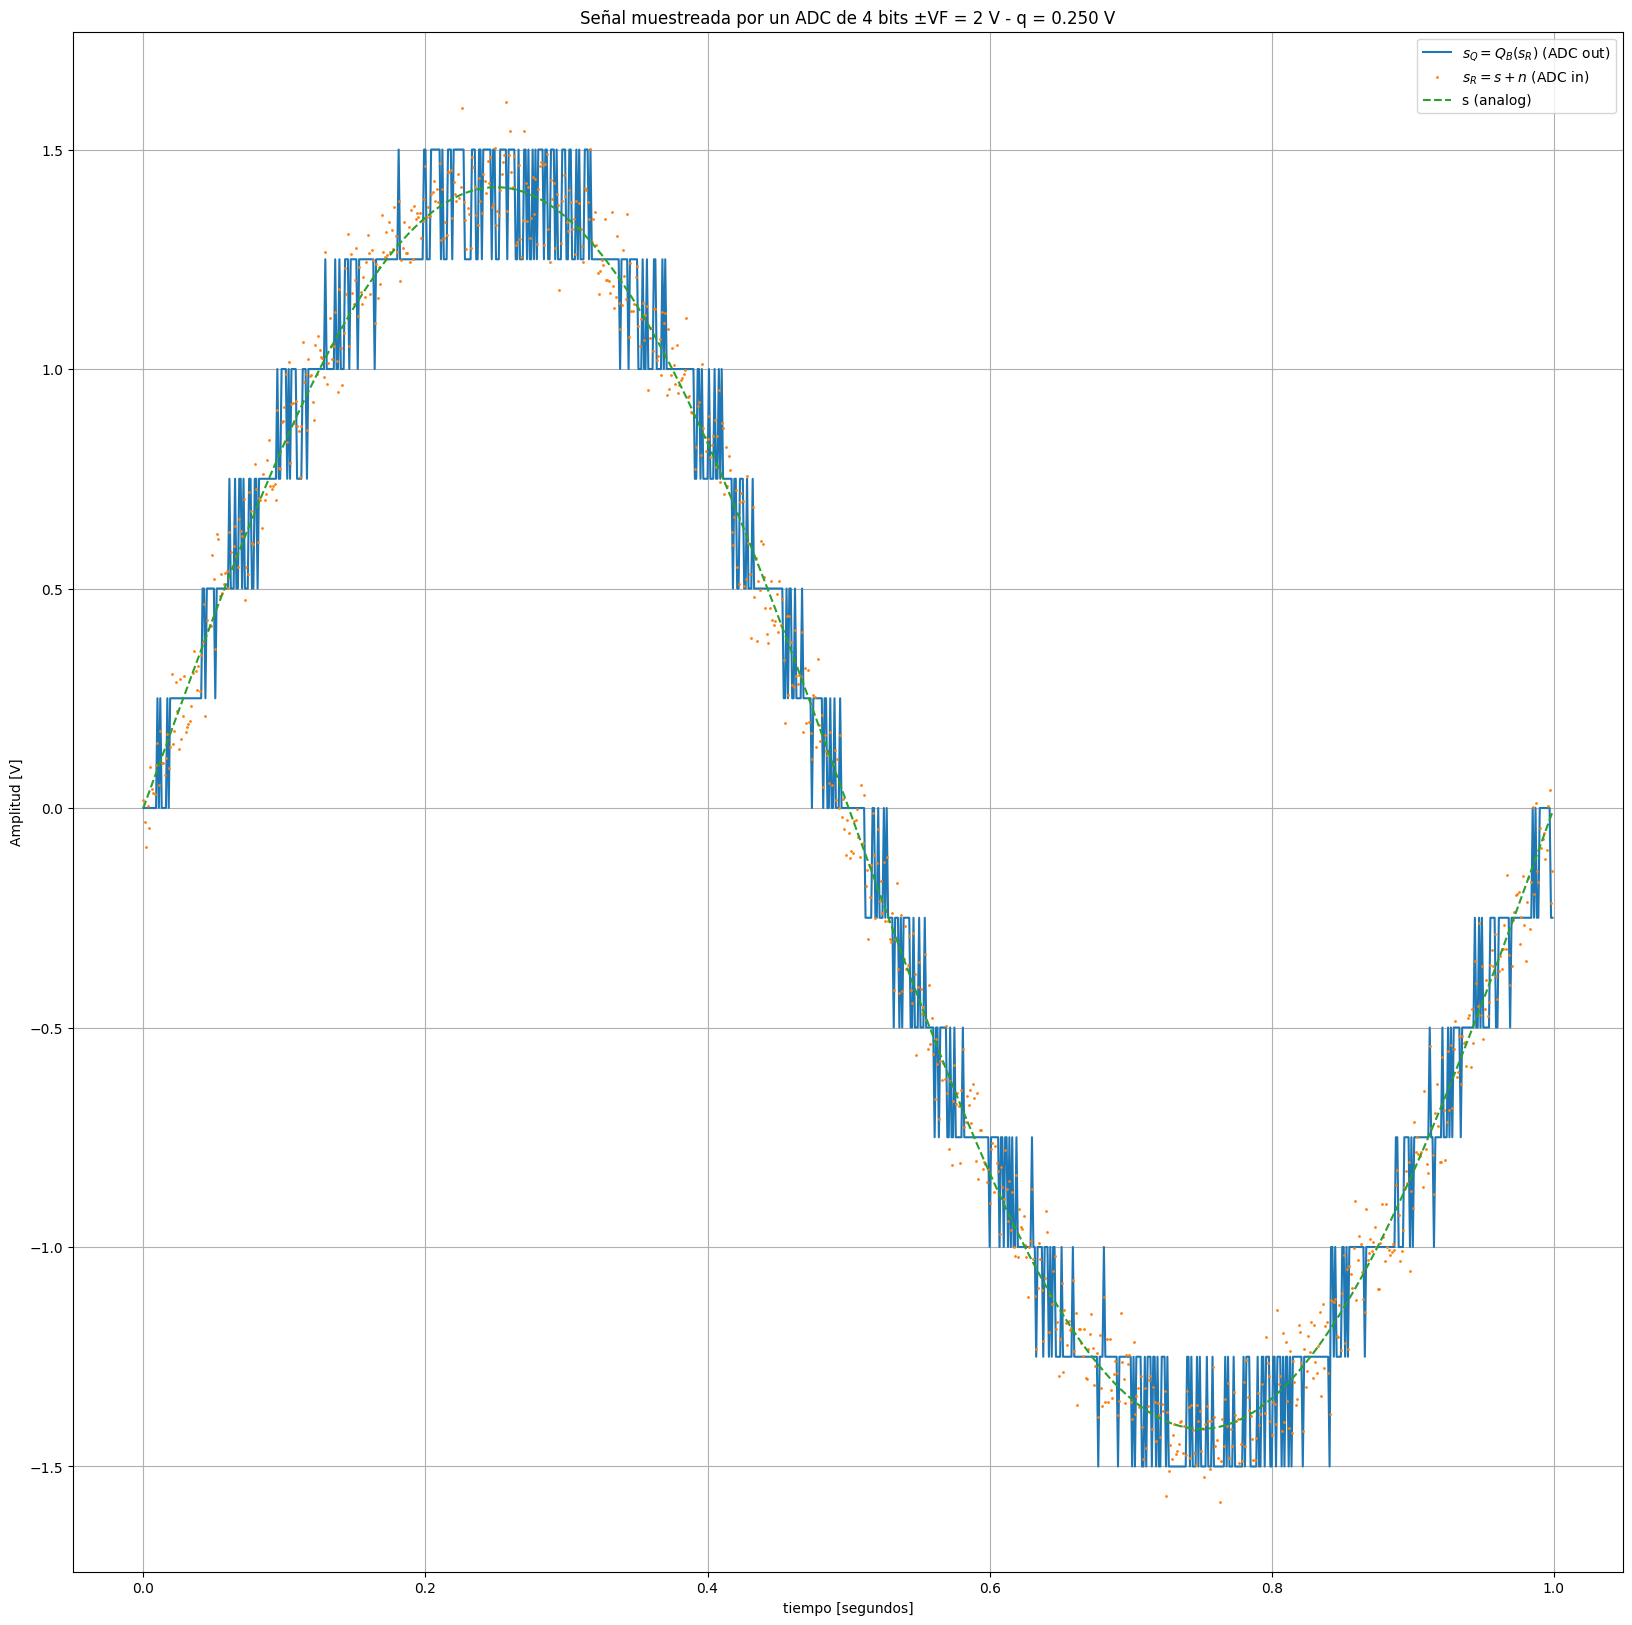

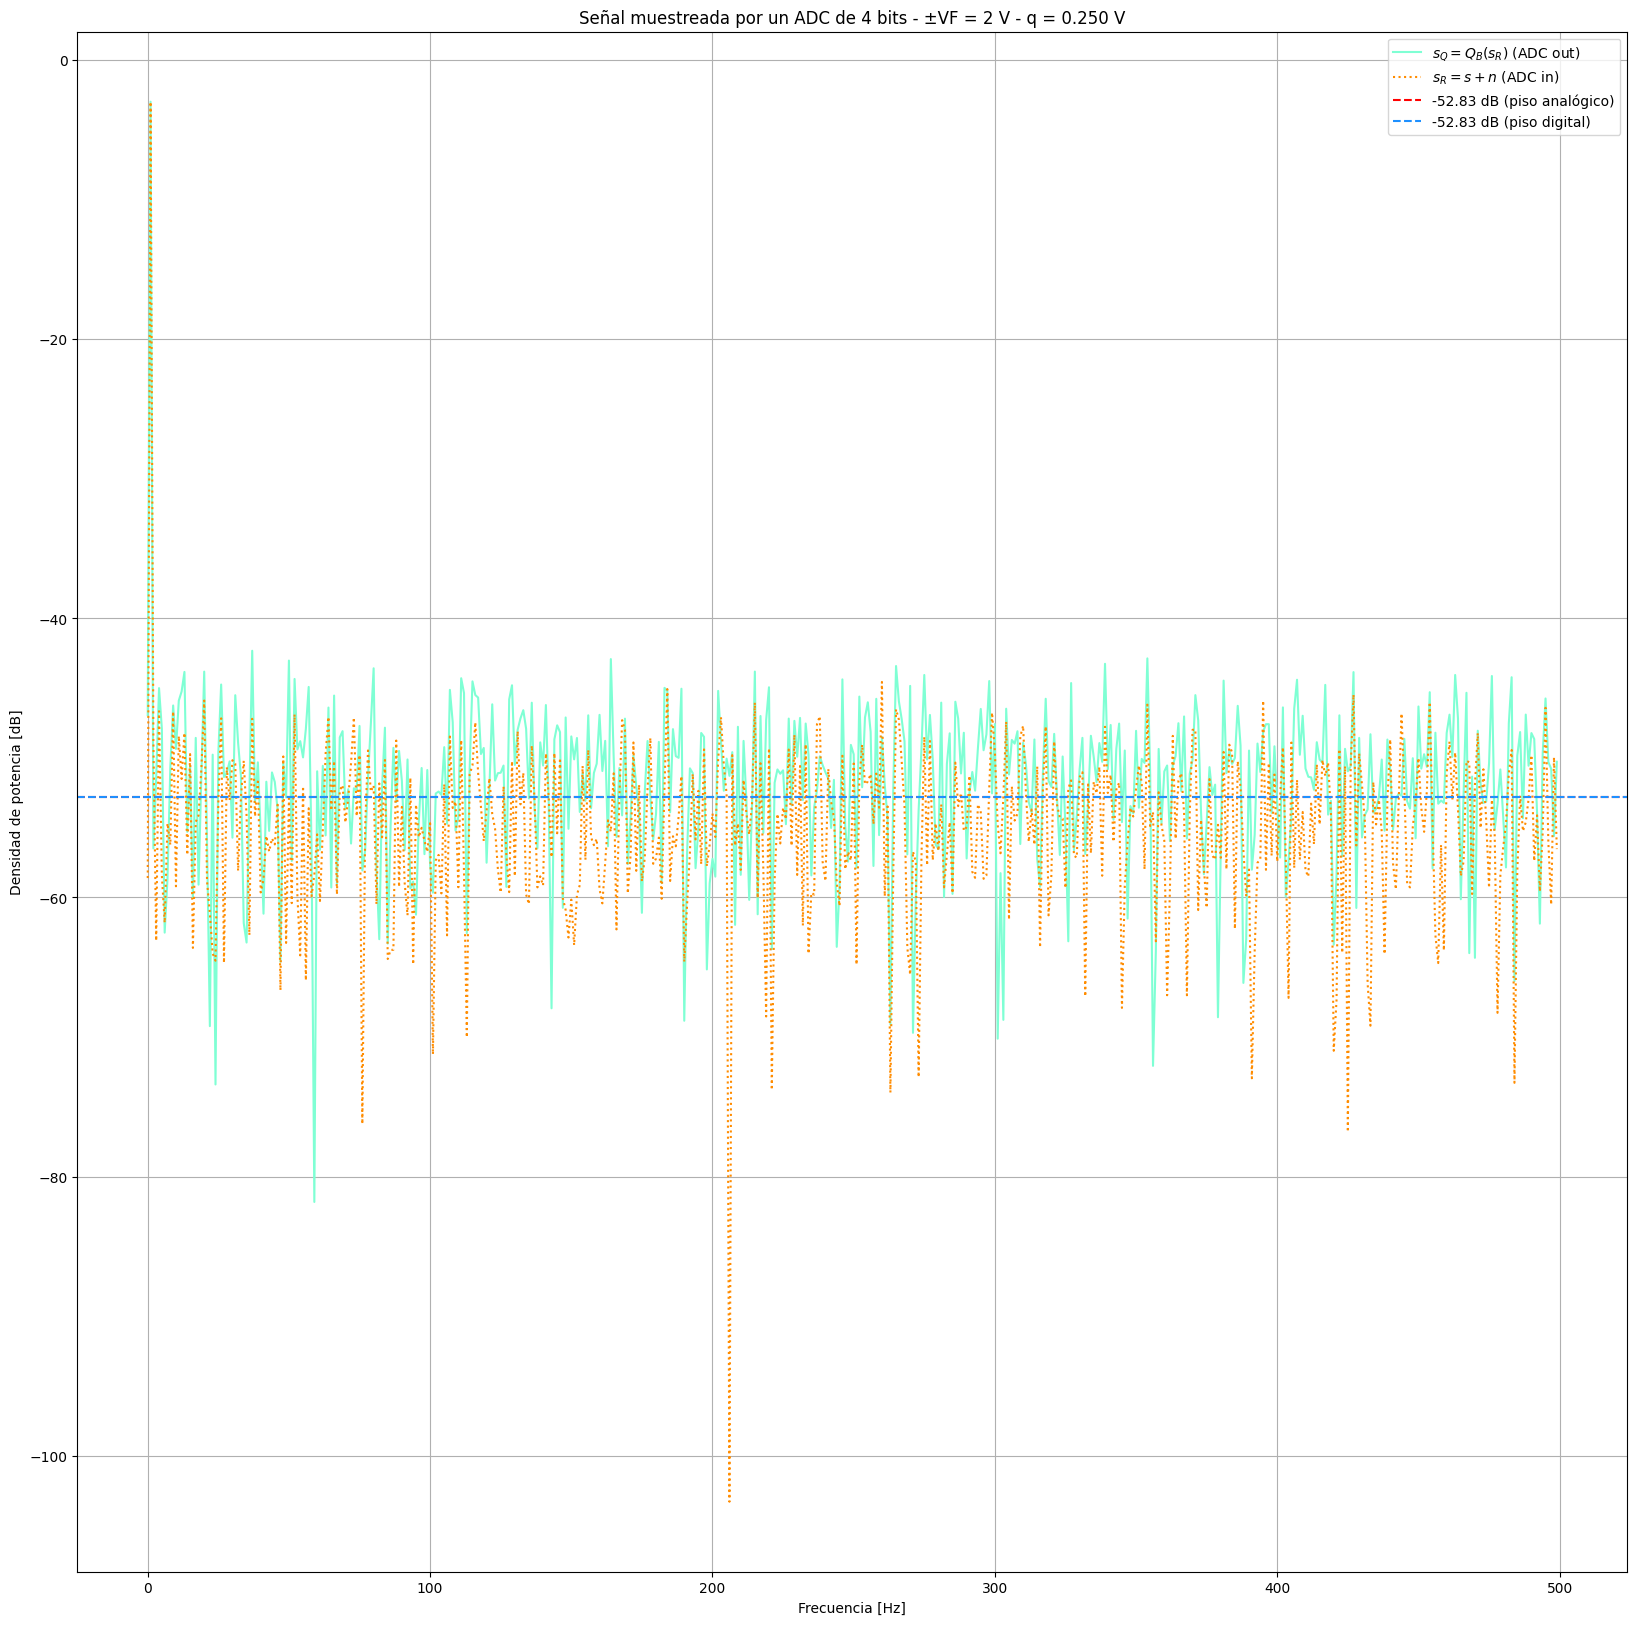

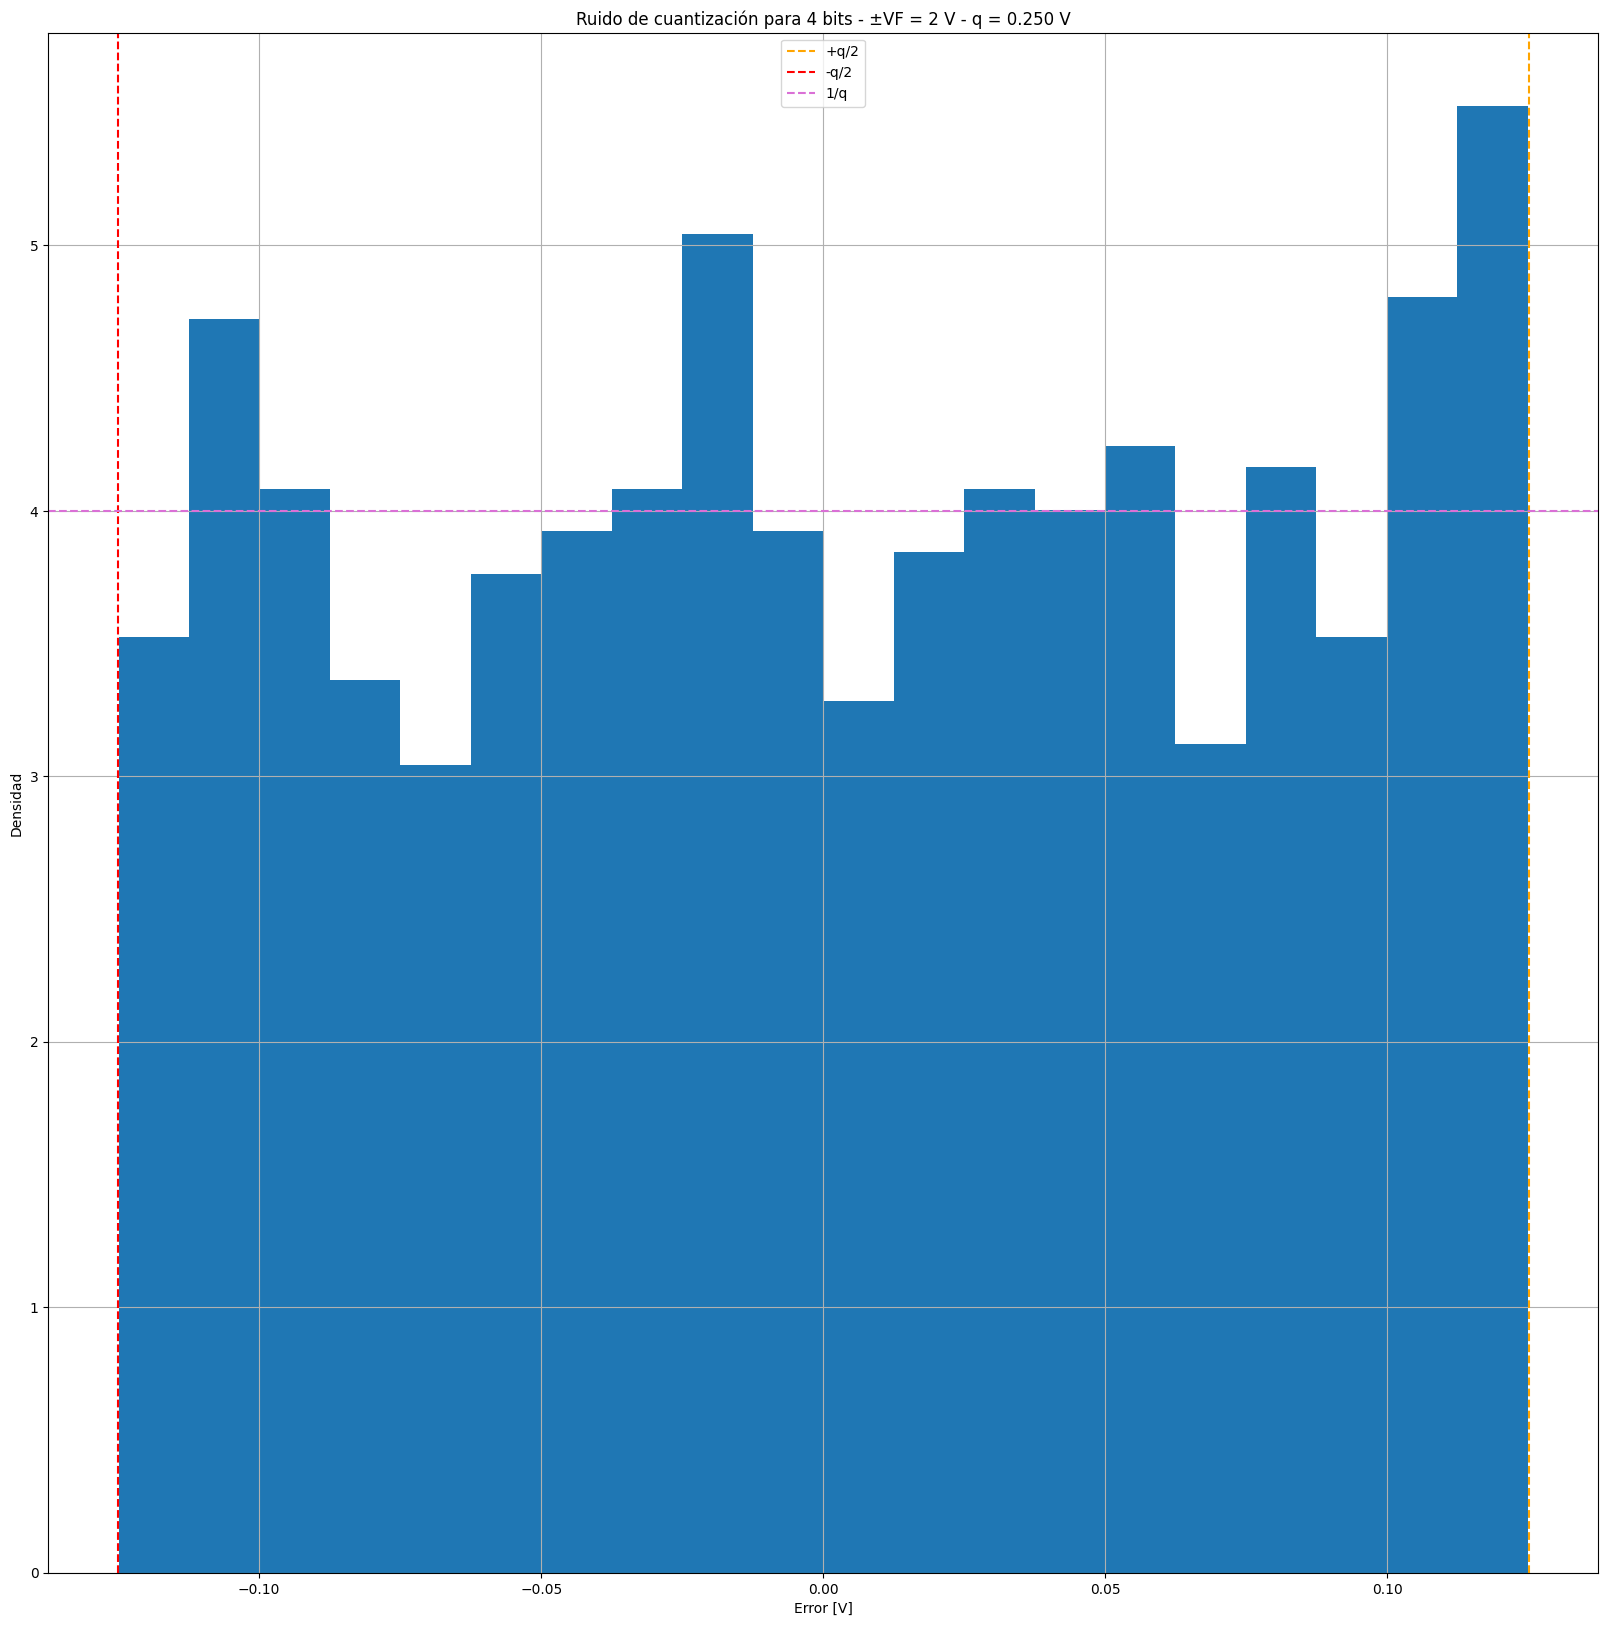

In [13]:
#%% LLamo a las librerias que se van a utilizar
import numpy as np
import matplotlib.pyplot as plt

#%% Item a
# Defino los parámetros a utilizar
fs = 1000          # Hz
n = 1000           # muestras
f0 = fs / n        # Hz
ts = 1/fs
tt = np.arange(n) * ts

# Señal (potencia unitaria)
vmax = np.sqrt(2)
dc = 0
xx = dc + vmax * np.sin(2*np.pi*f0*tt)

#%% ADC 
B = 4
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 1
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn / (n))
piso_digital = 10 * np.log10(Pq / (n))

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()

b) 4 Bits y K = 1/10

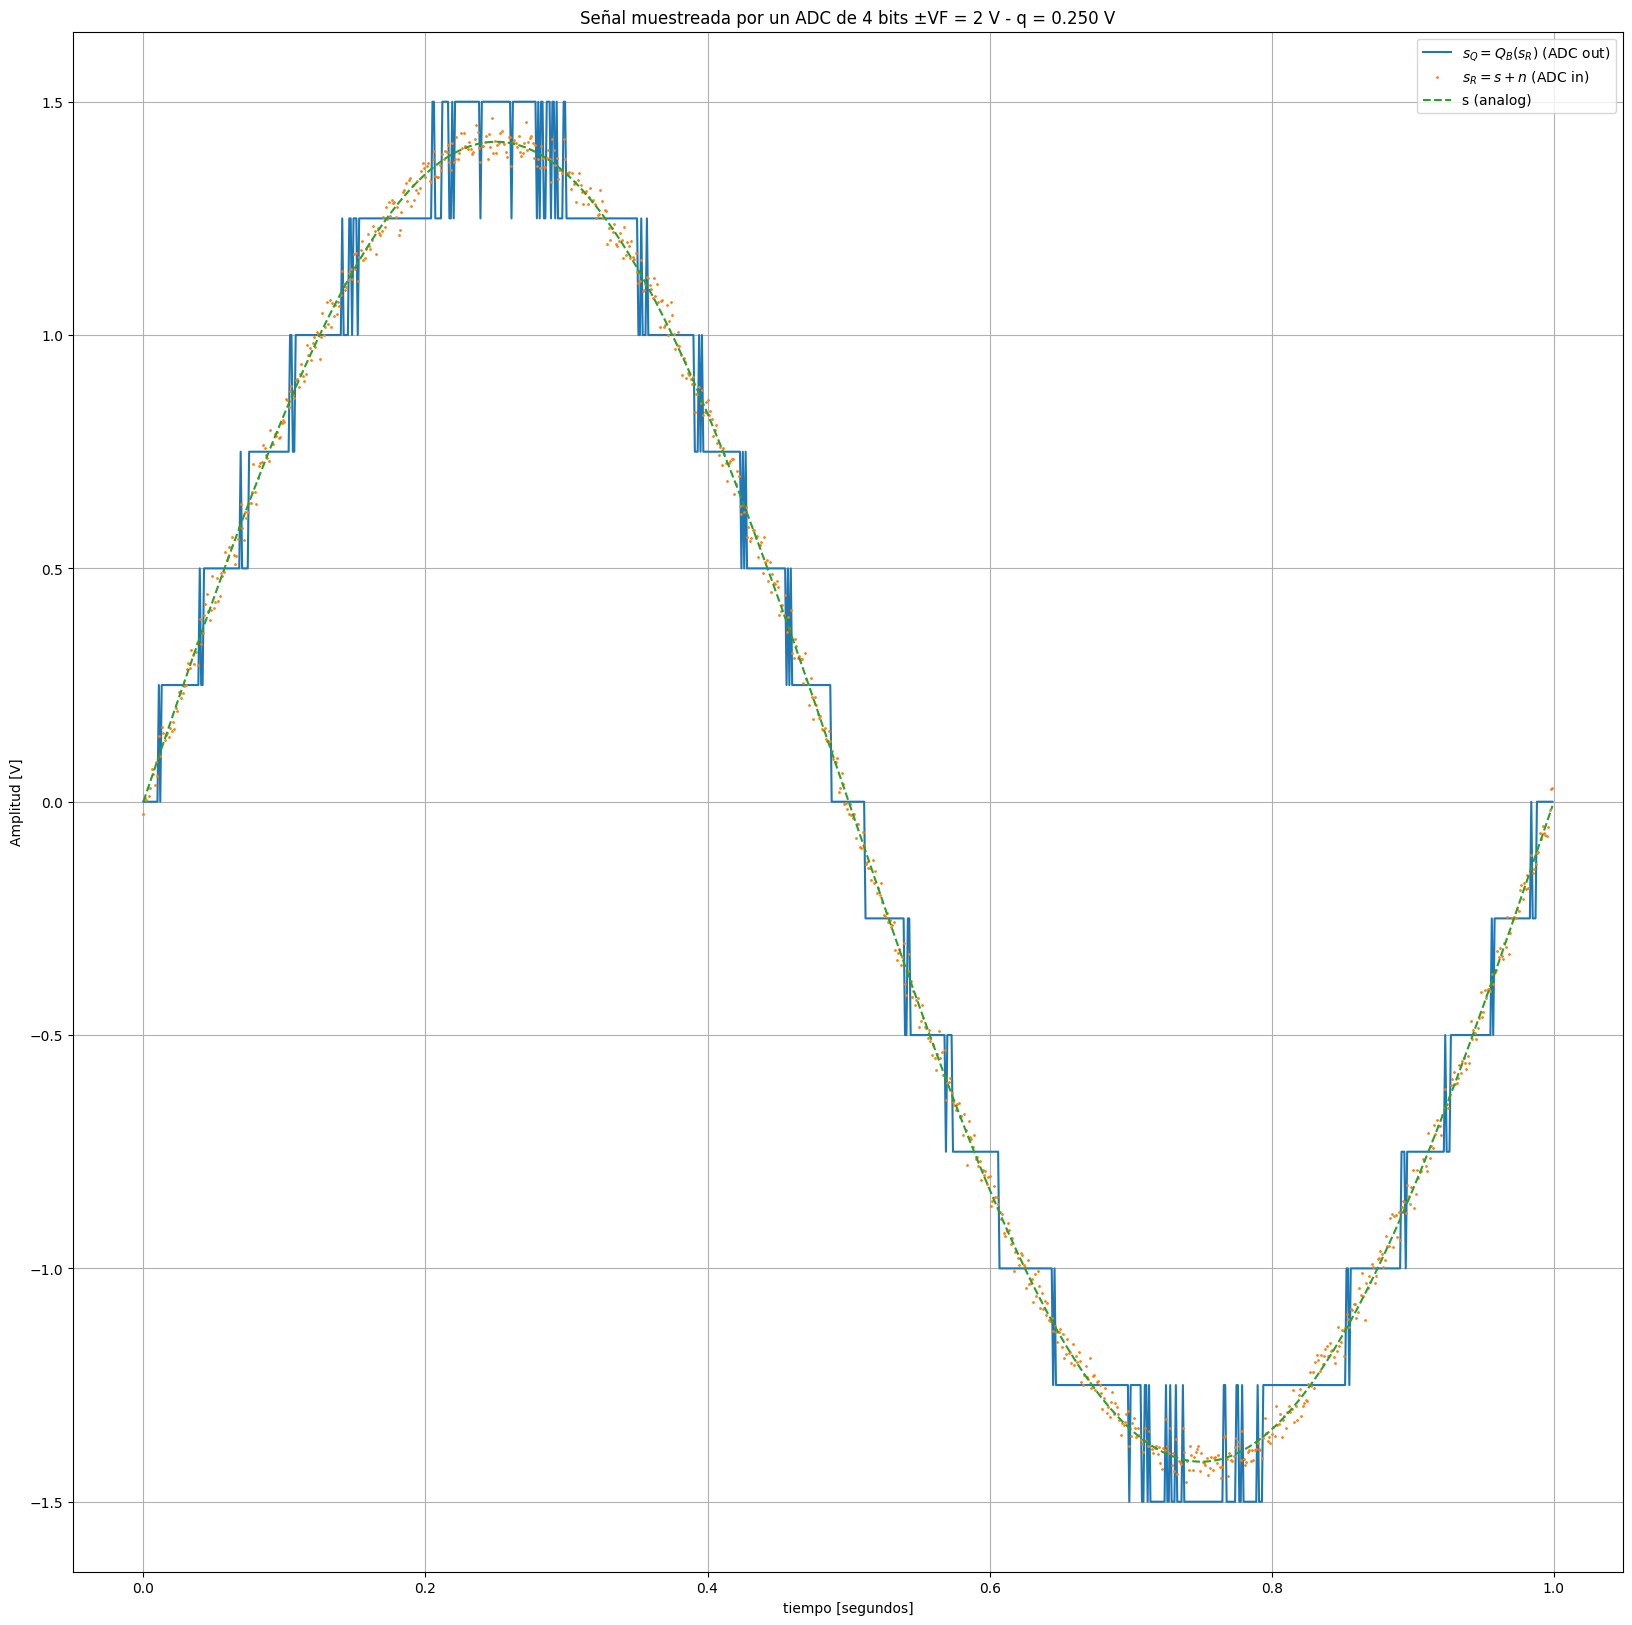

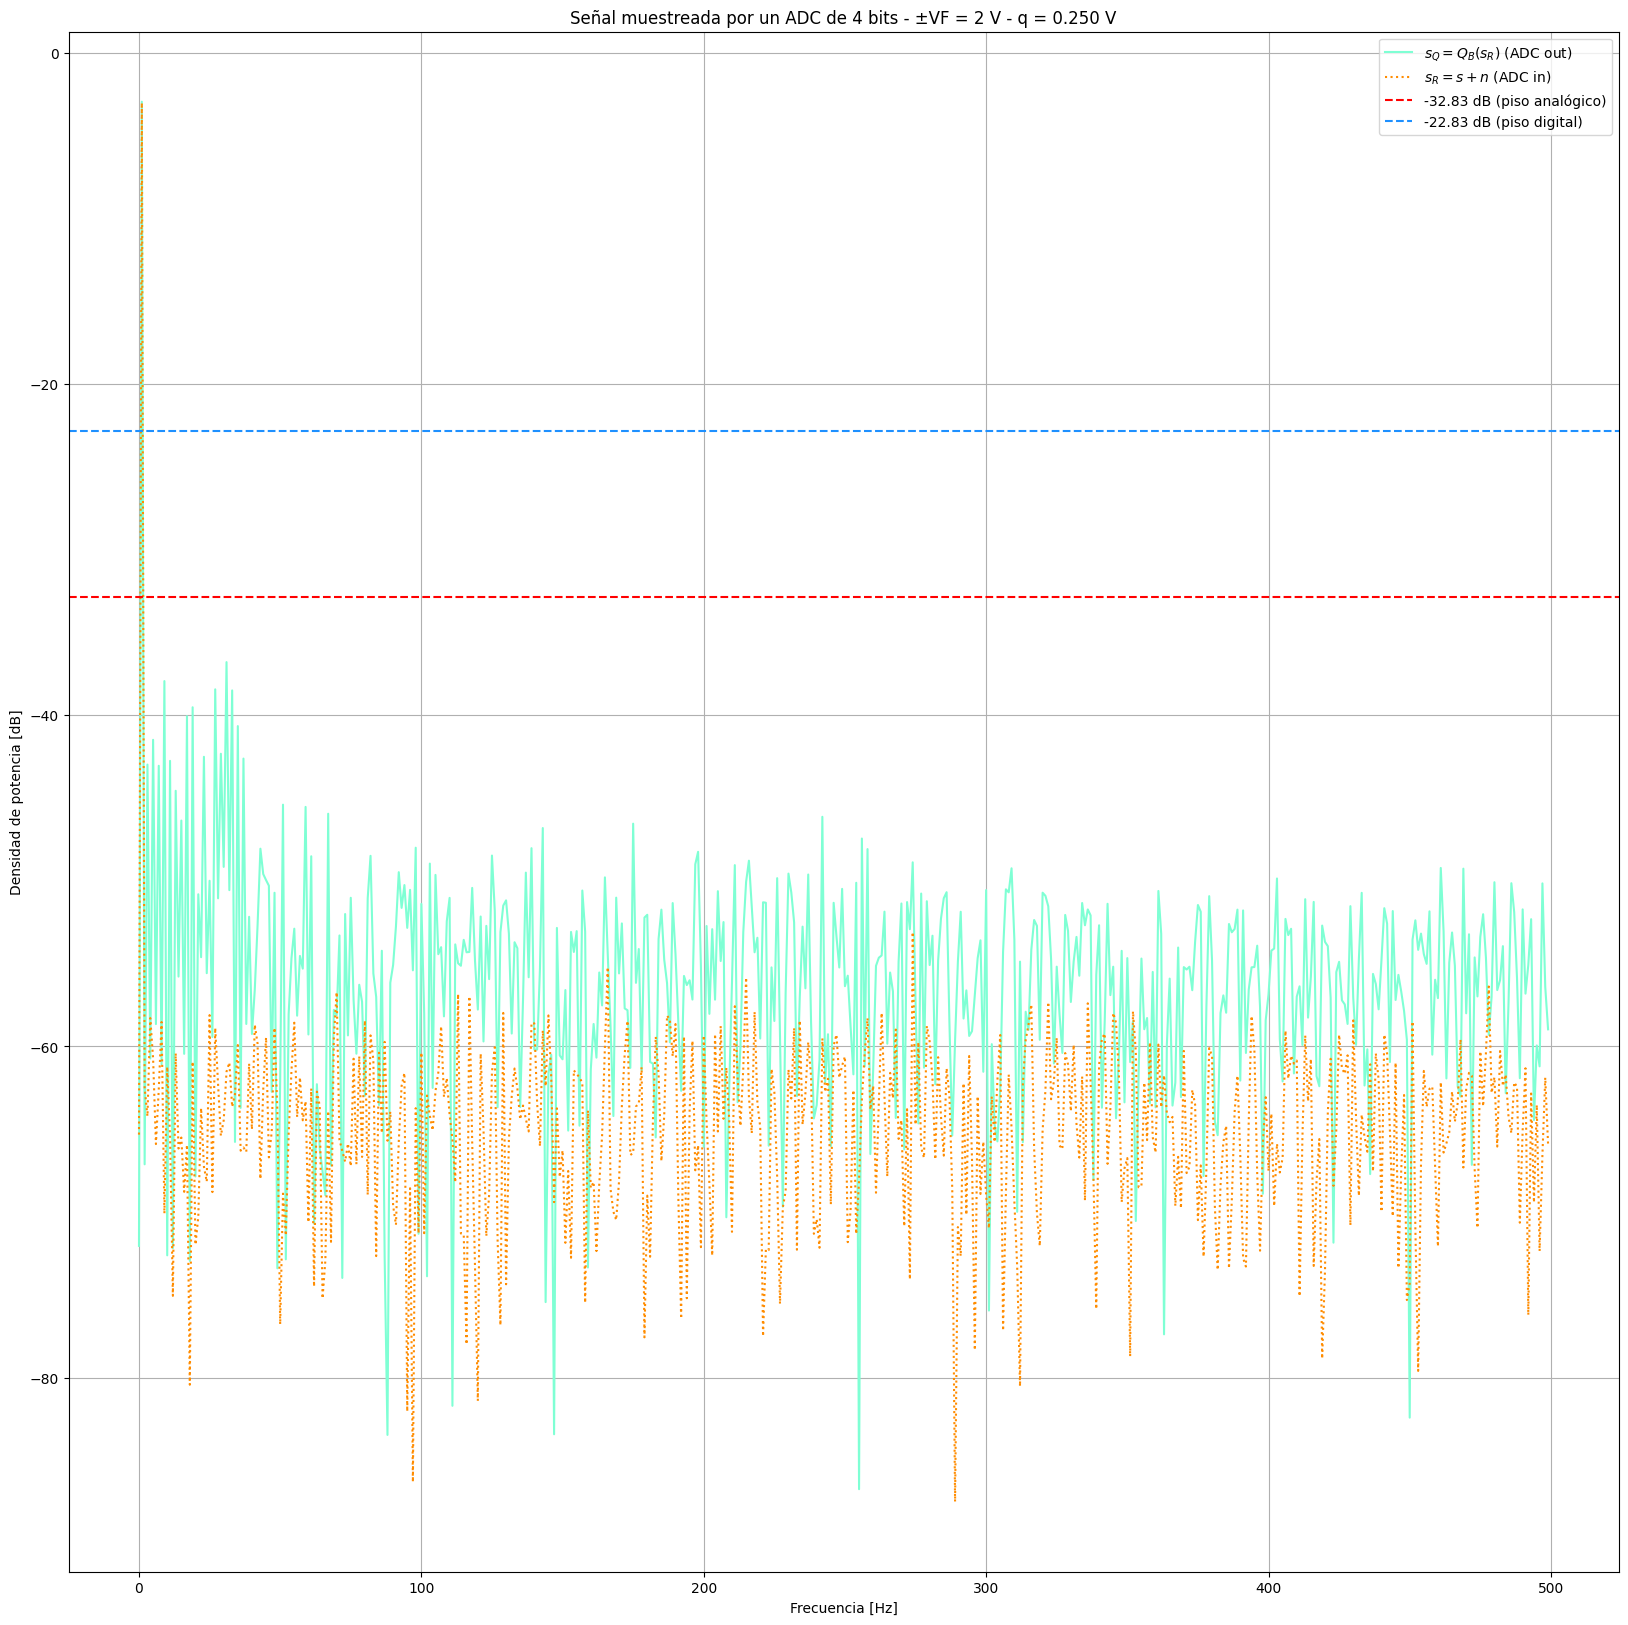

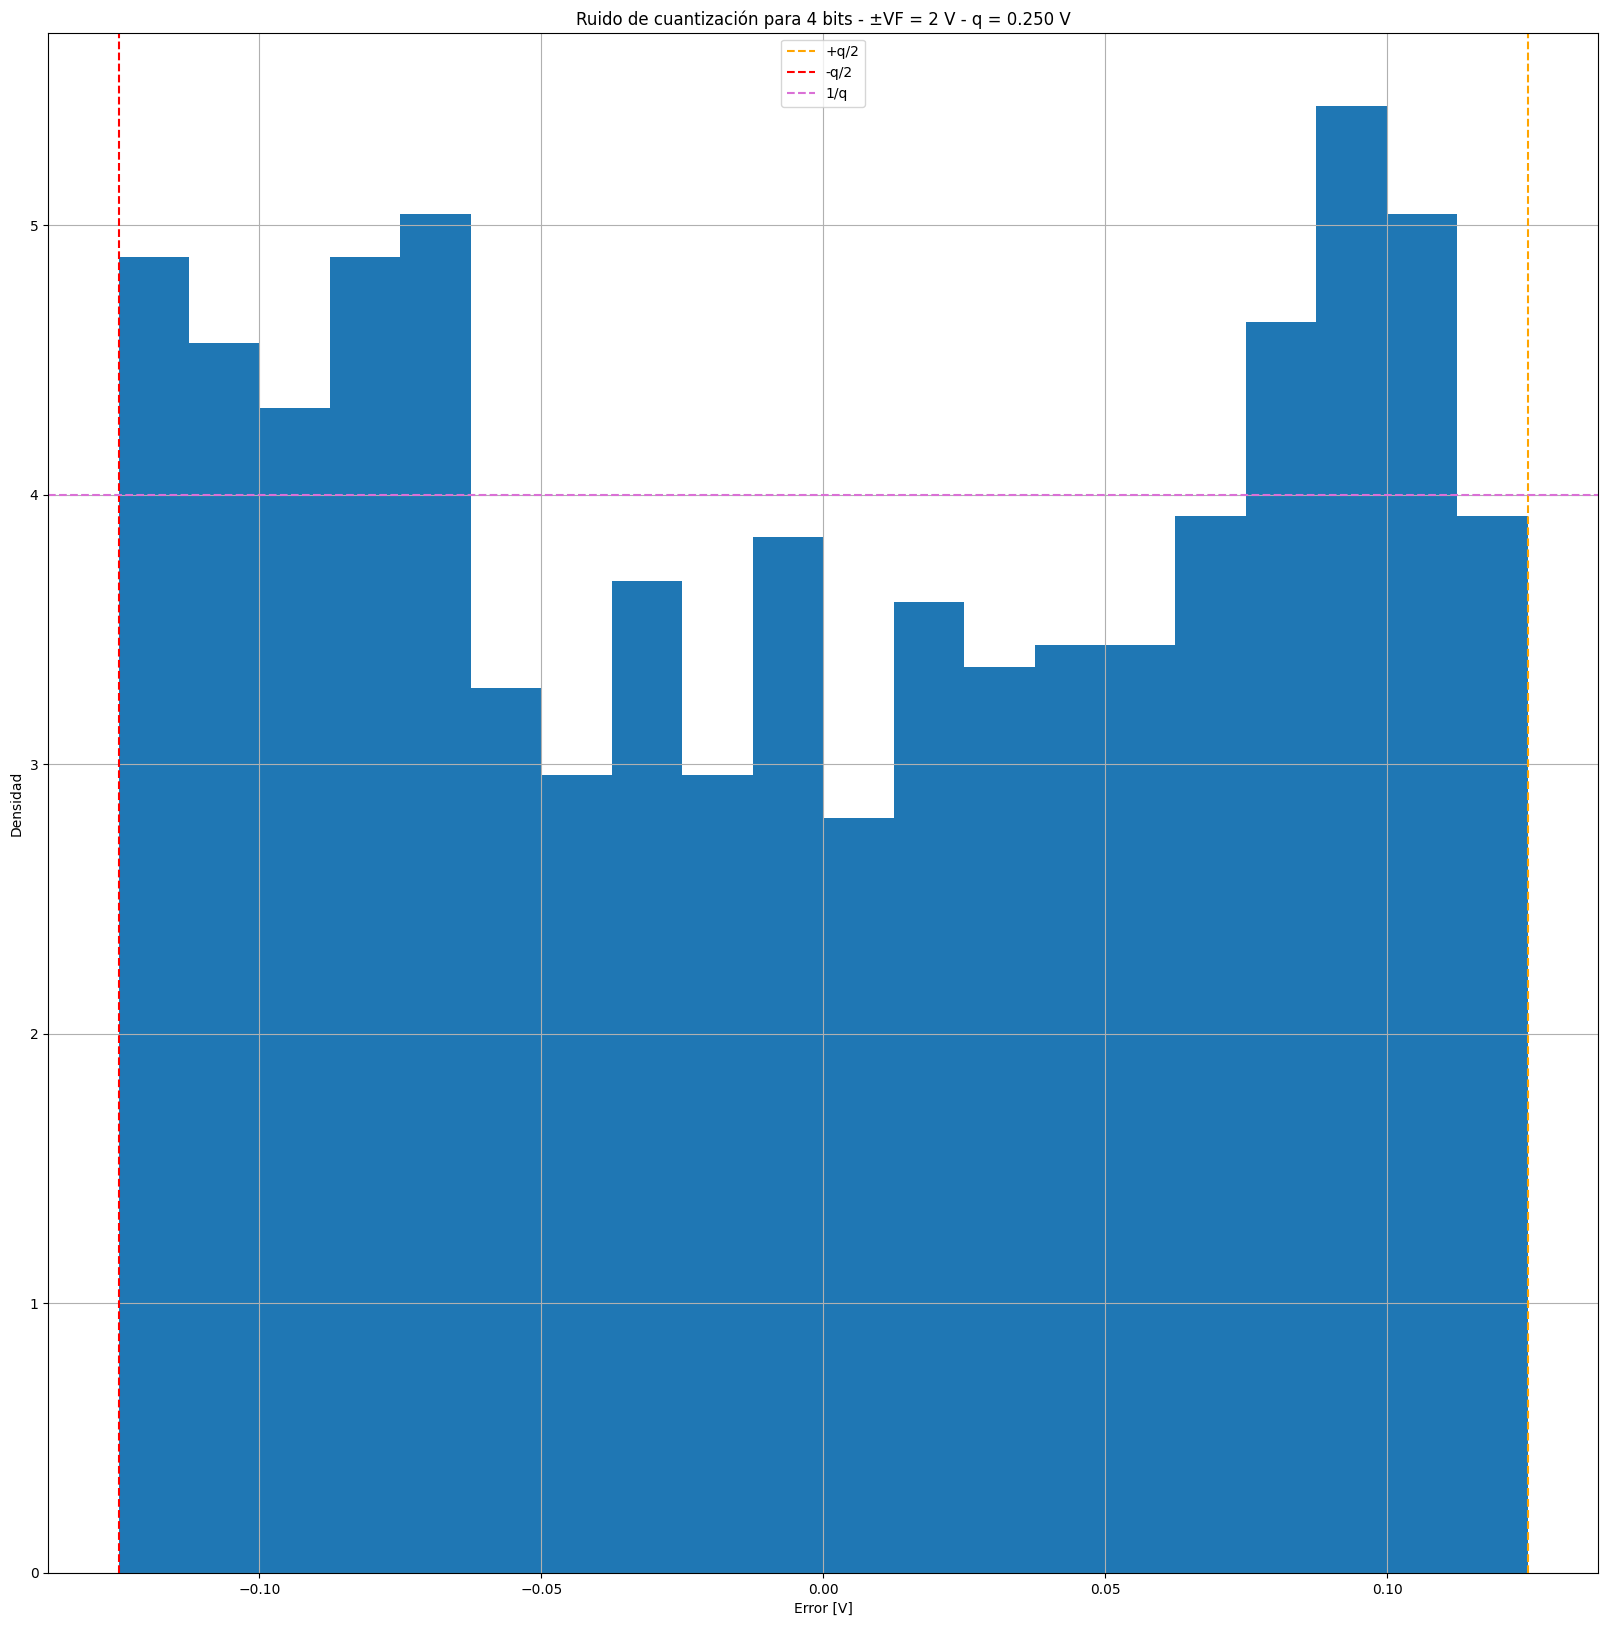

In [14]:
#%% ADC (4 bits y k = 1/10)
# Defino el ruido
kn = 1/10
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()

8 Bits y K = 1

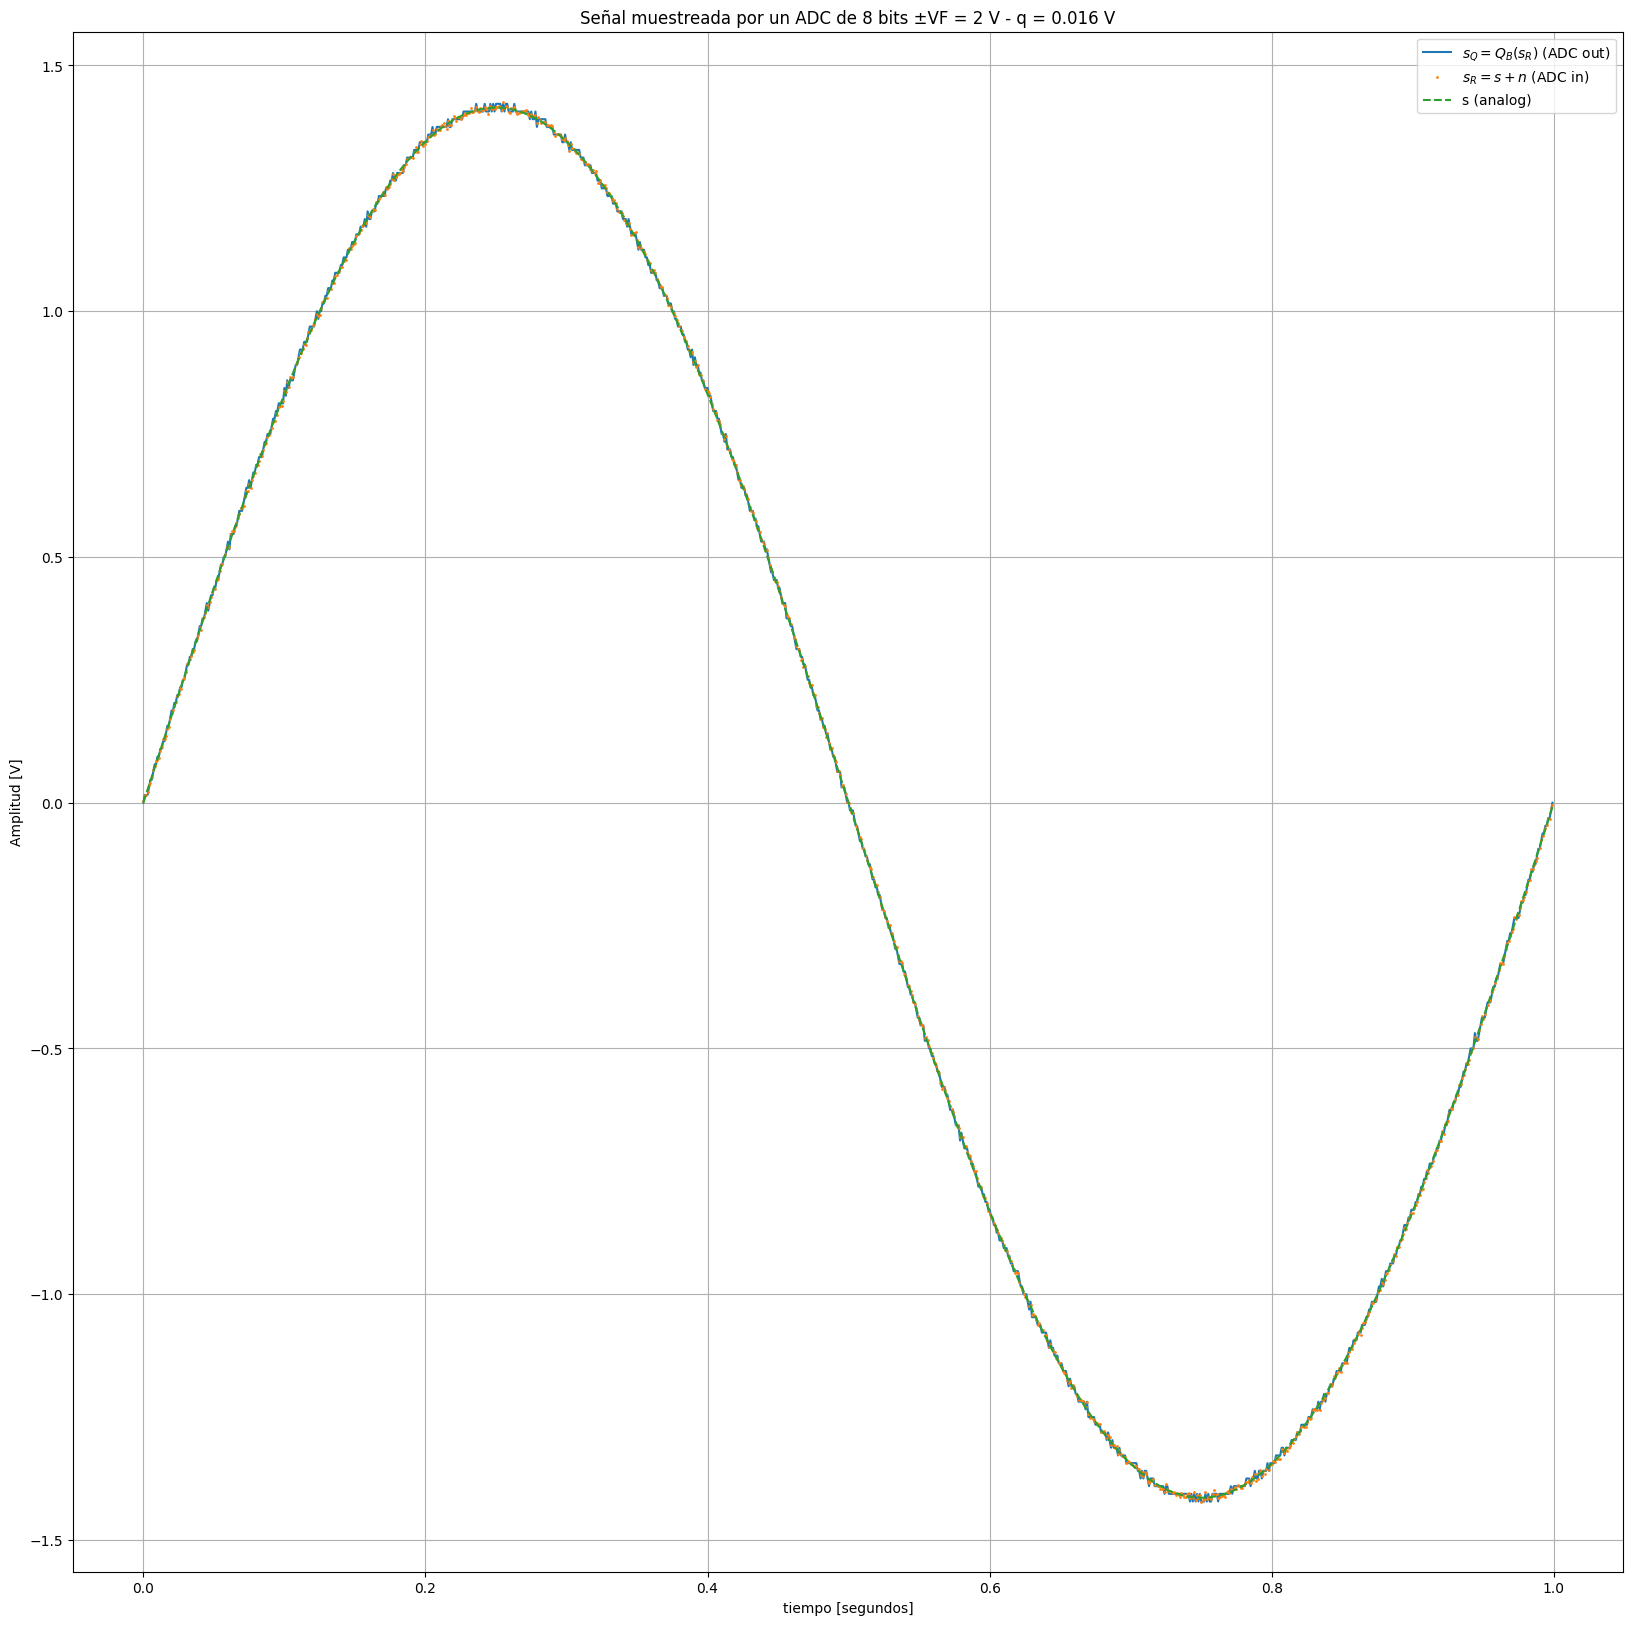

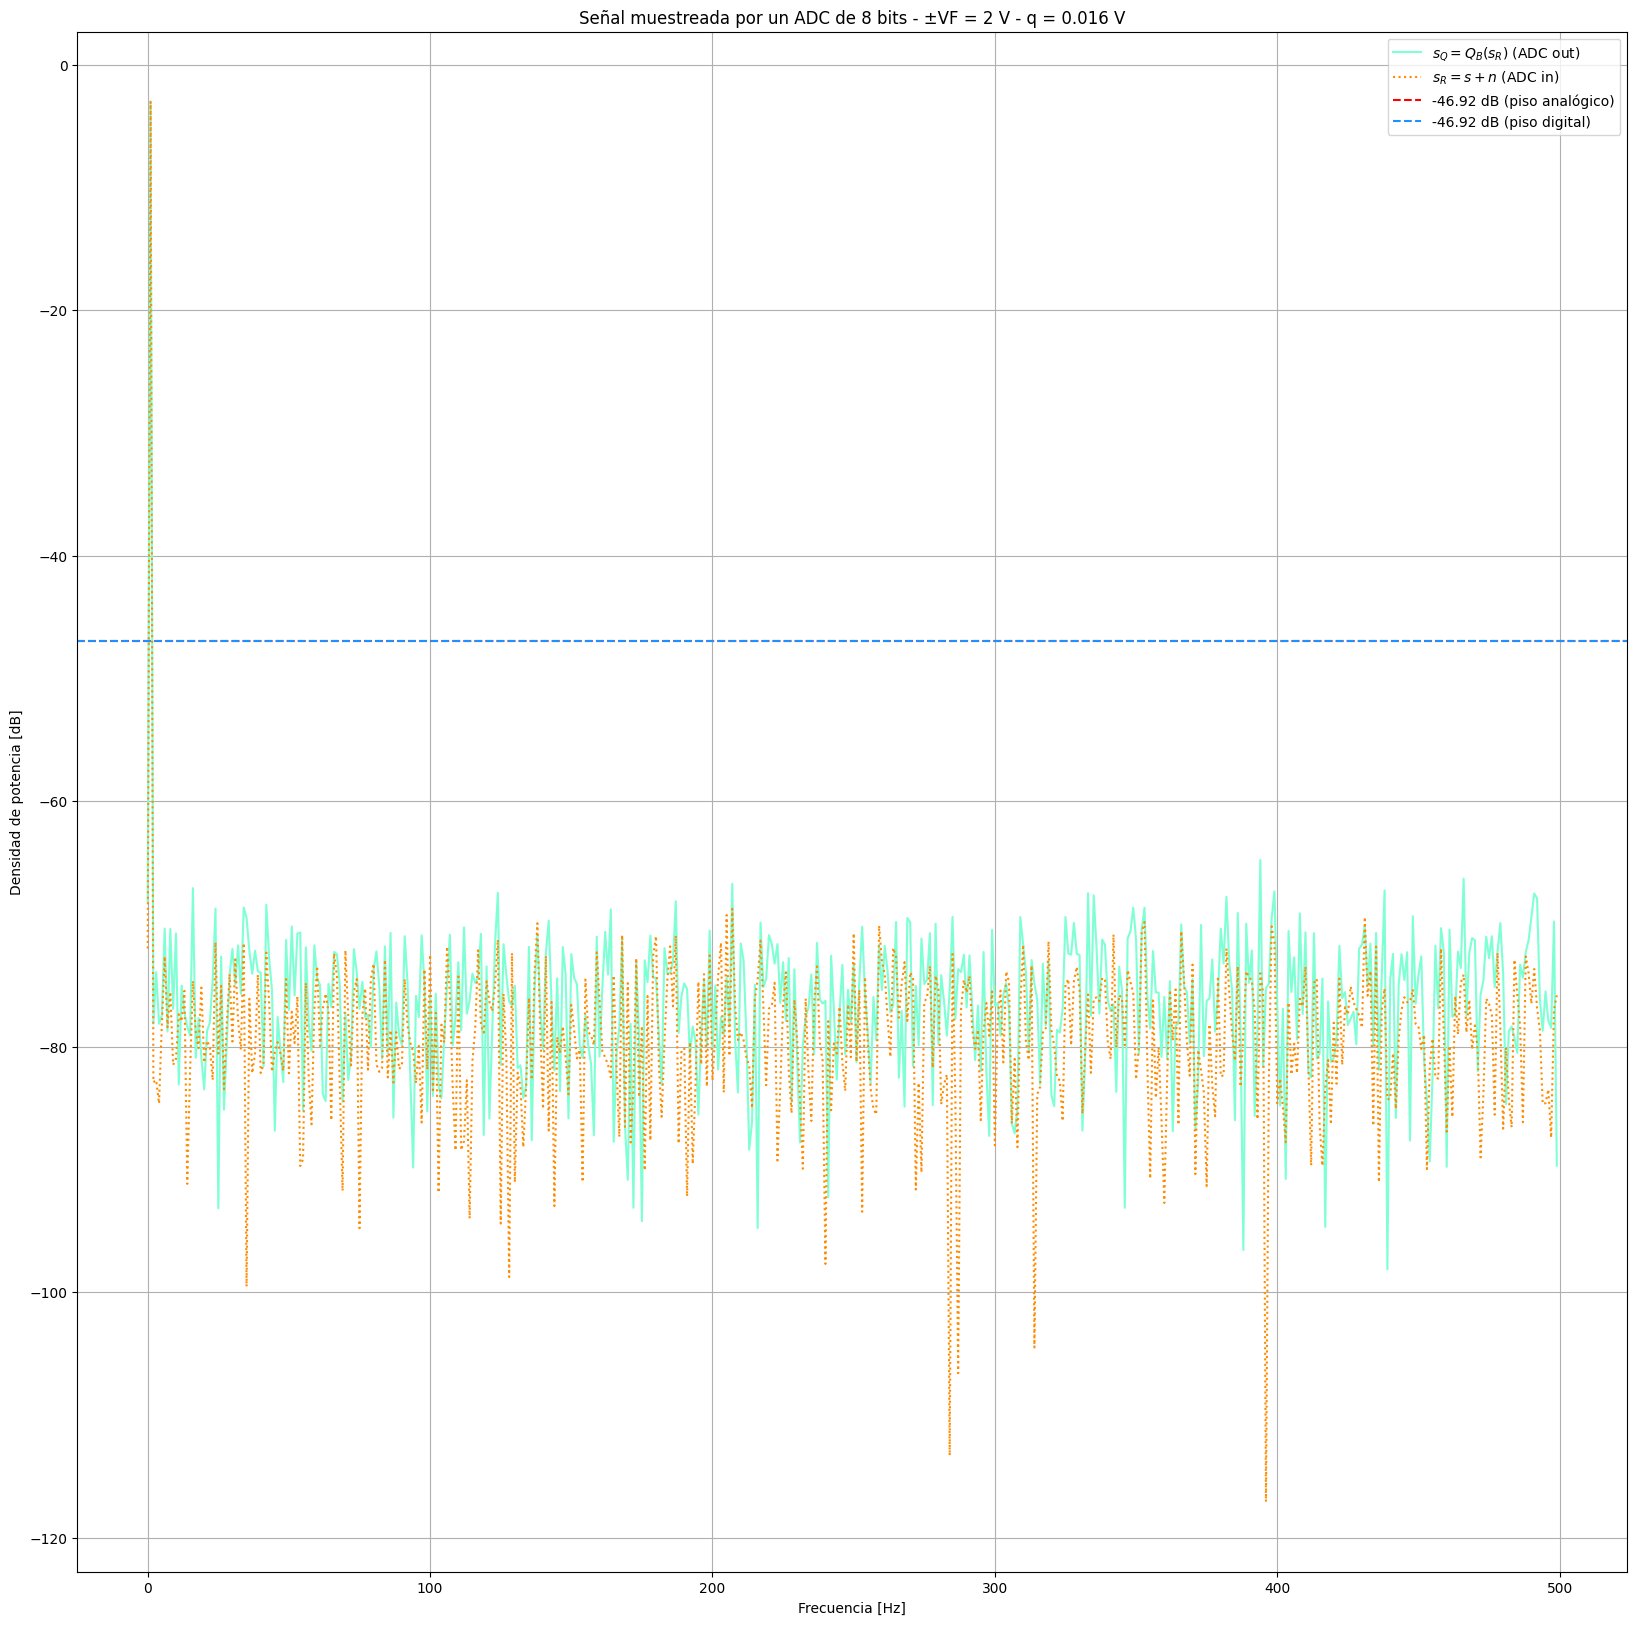

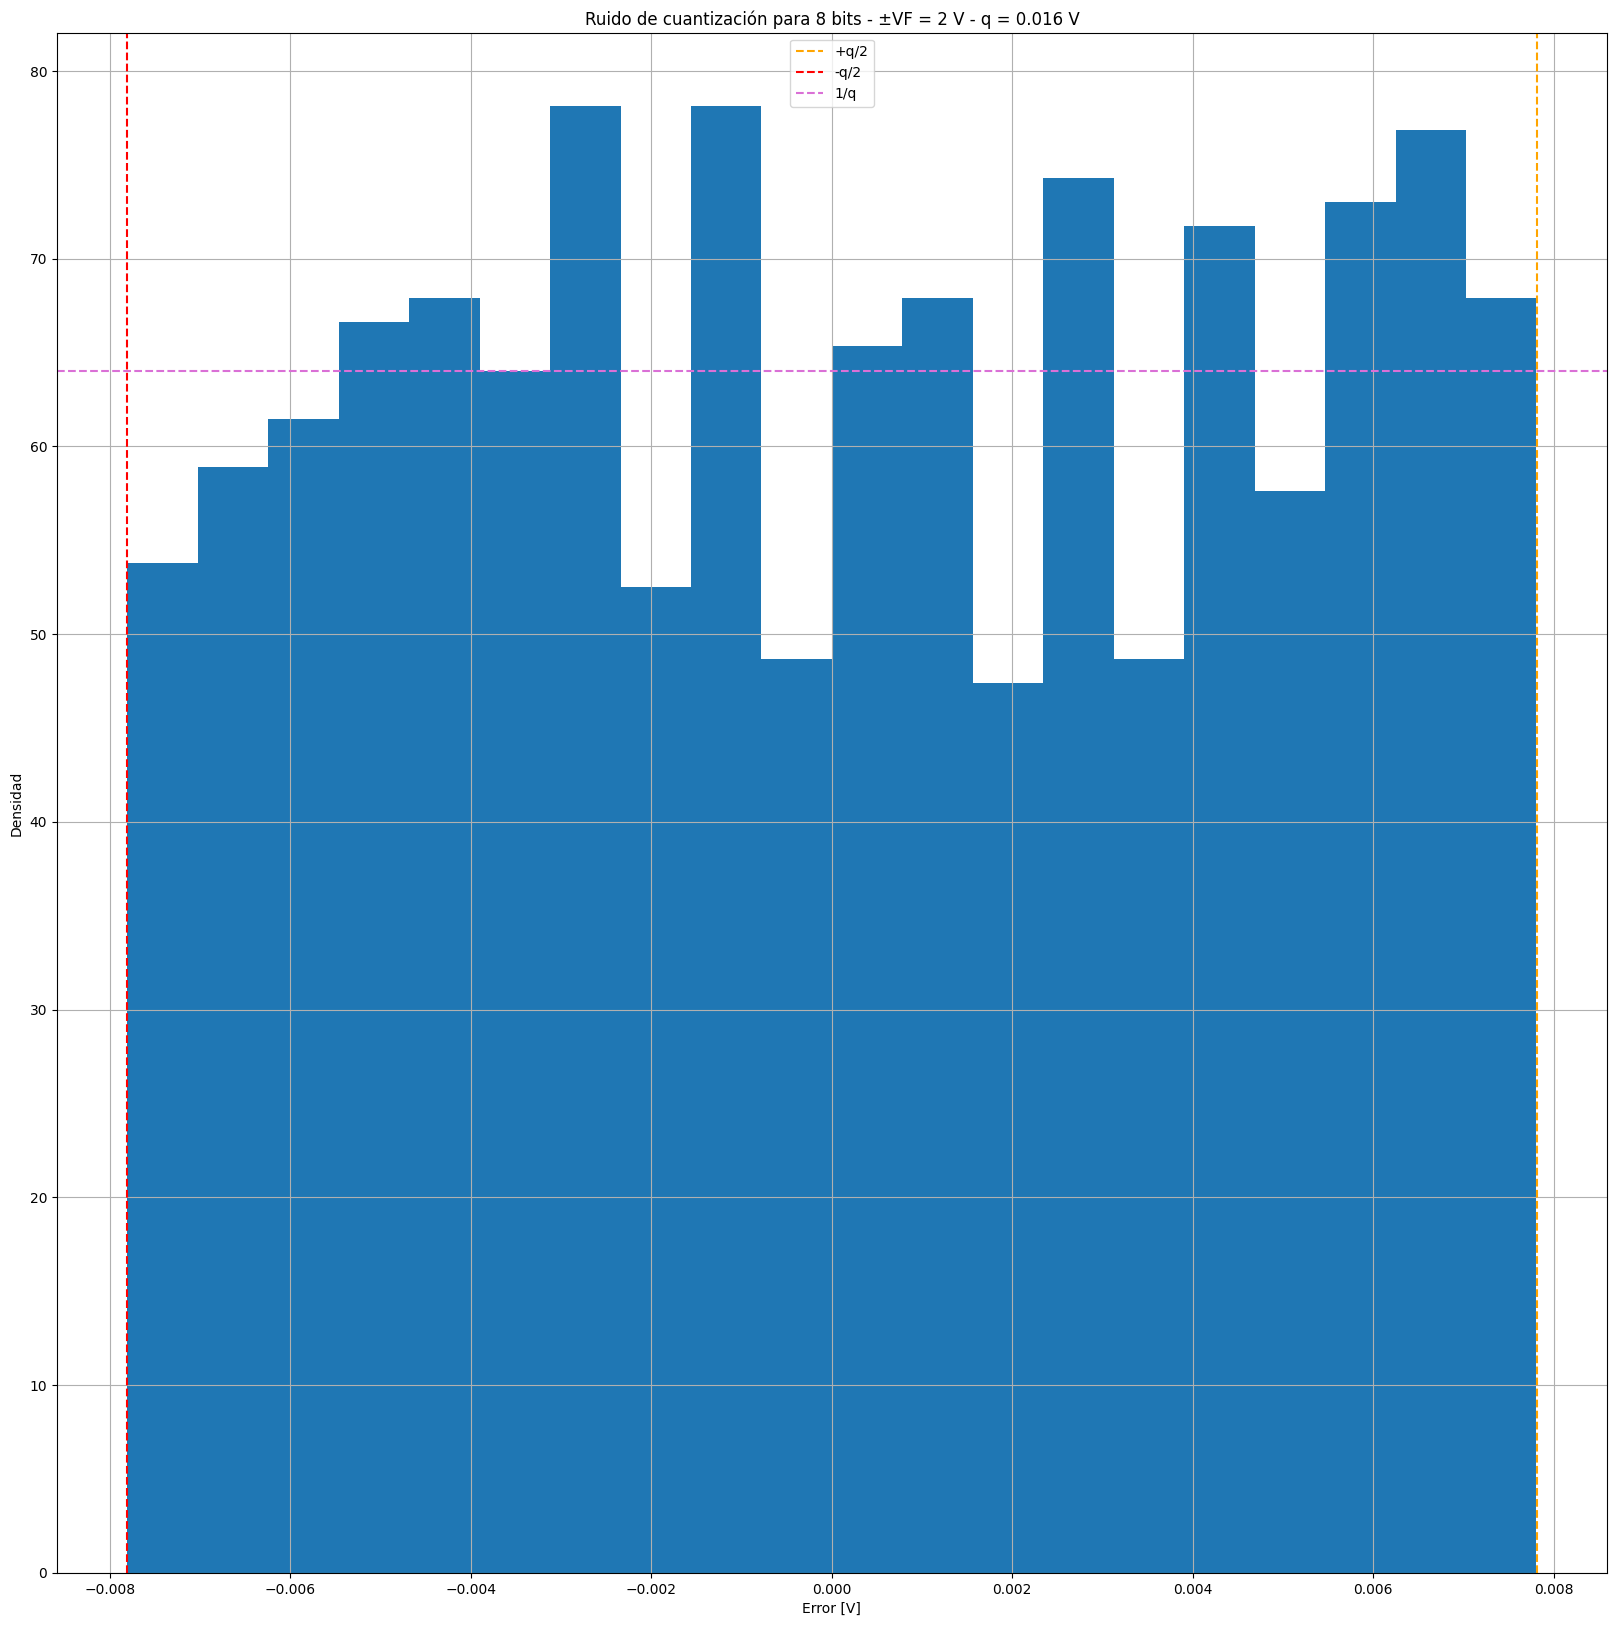

In [15]:
#%% ADC (8 bits y k = 1)
B = 8
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 1
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()


16 Bits y k = 10

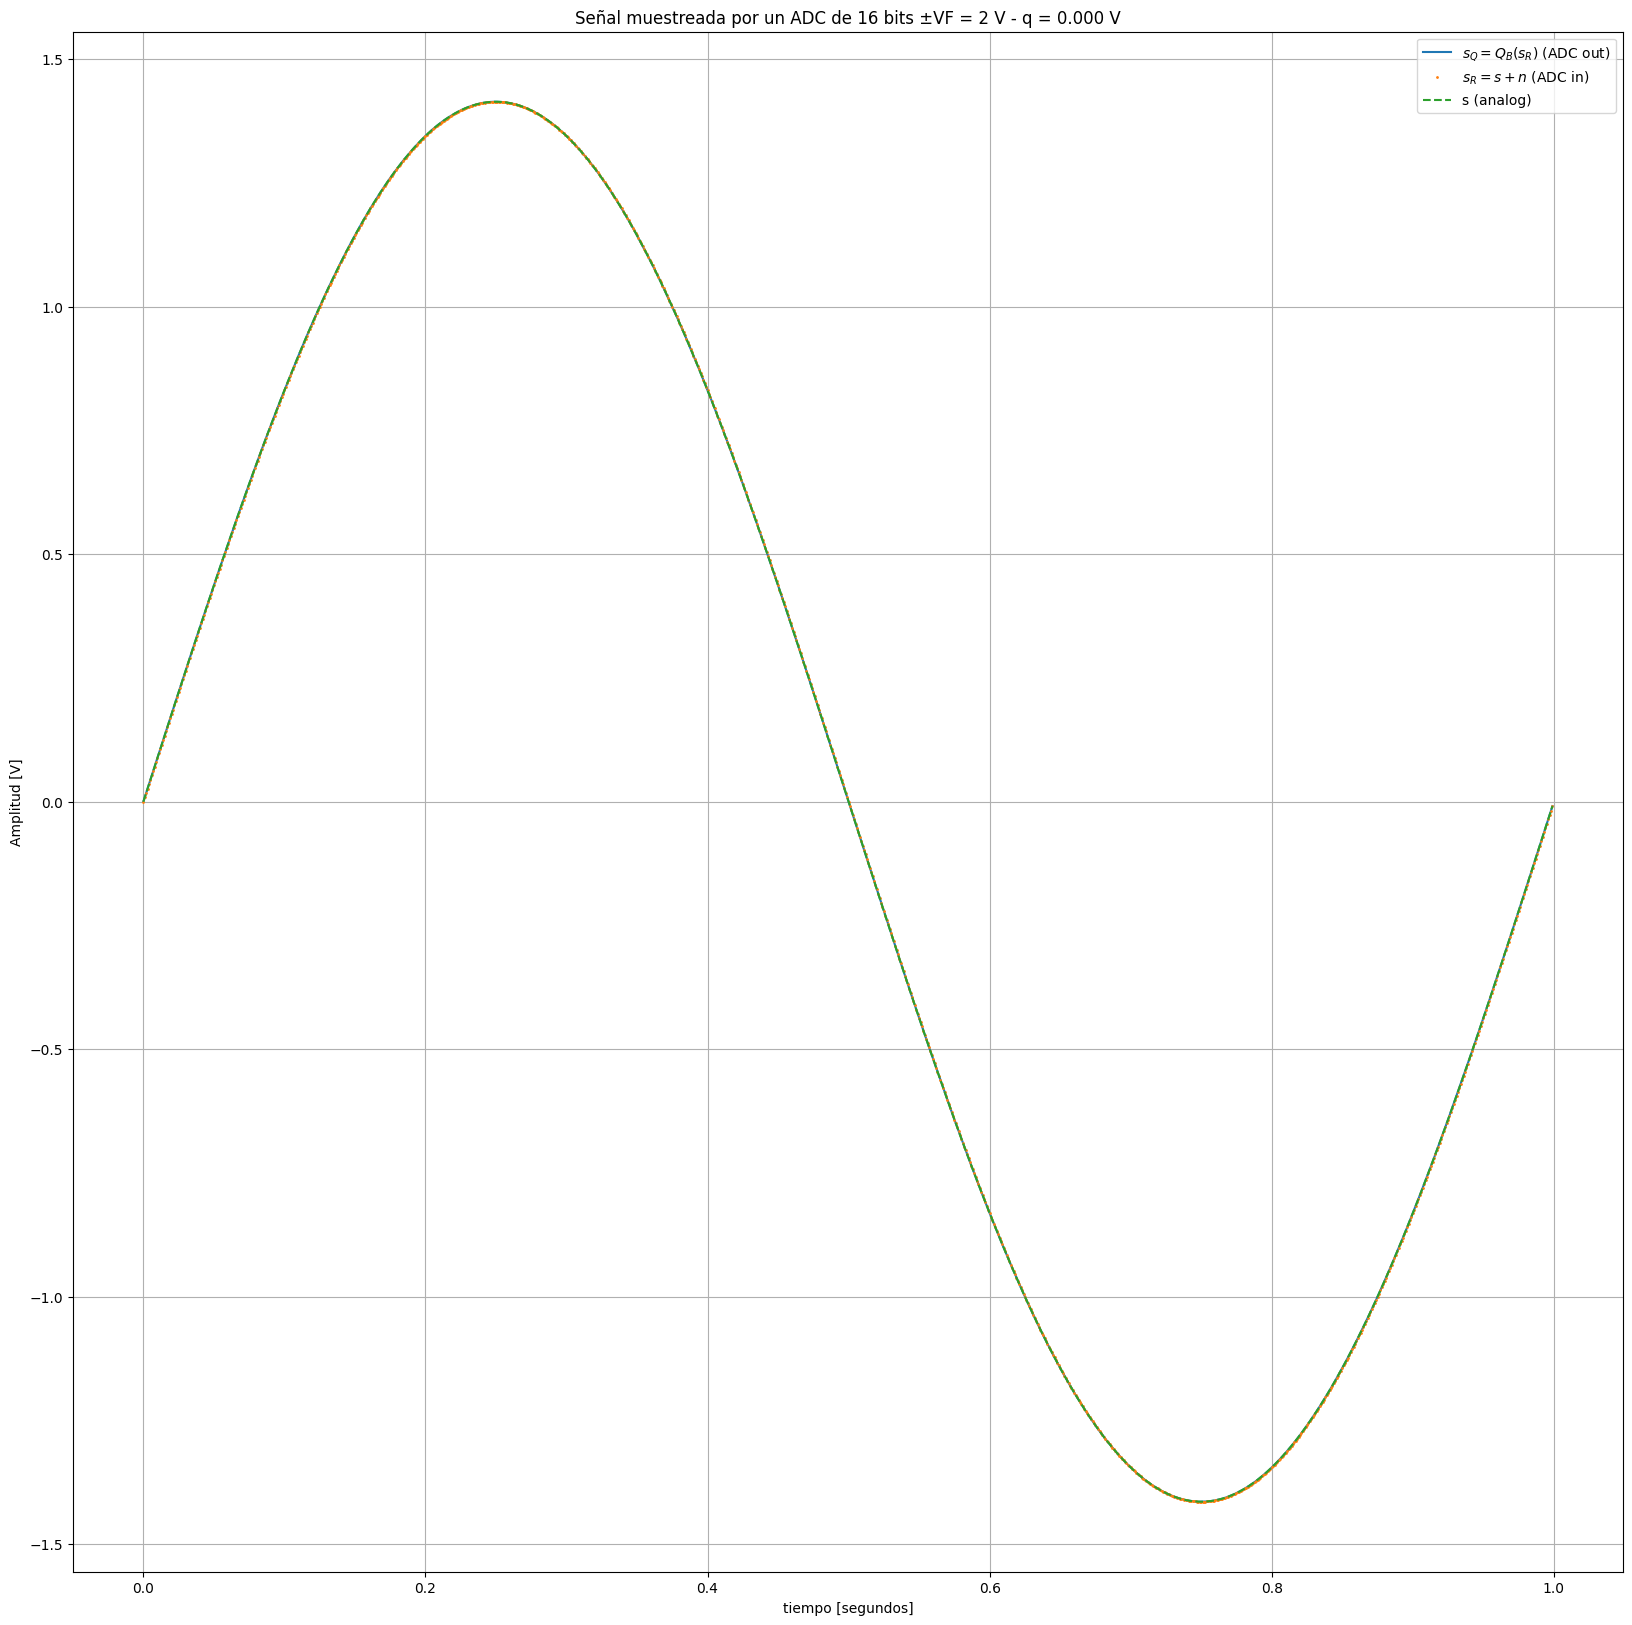

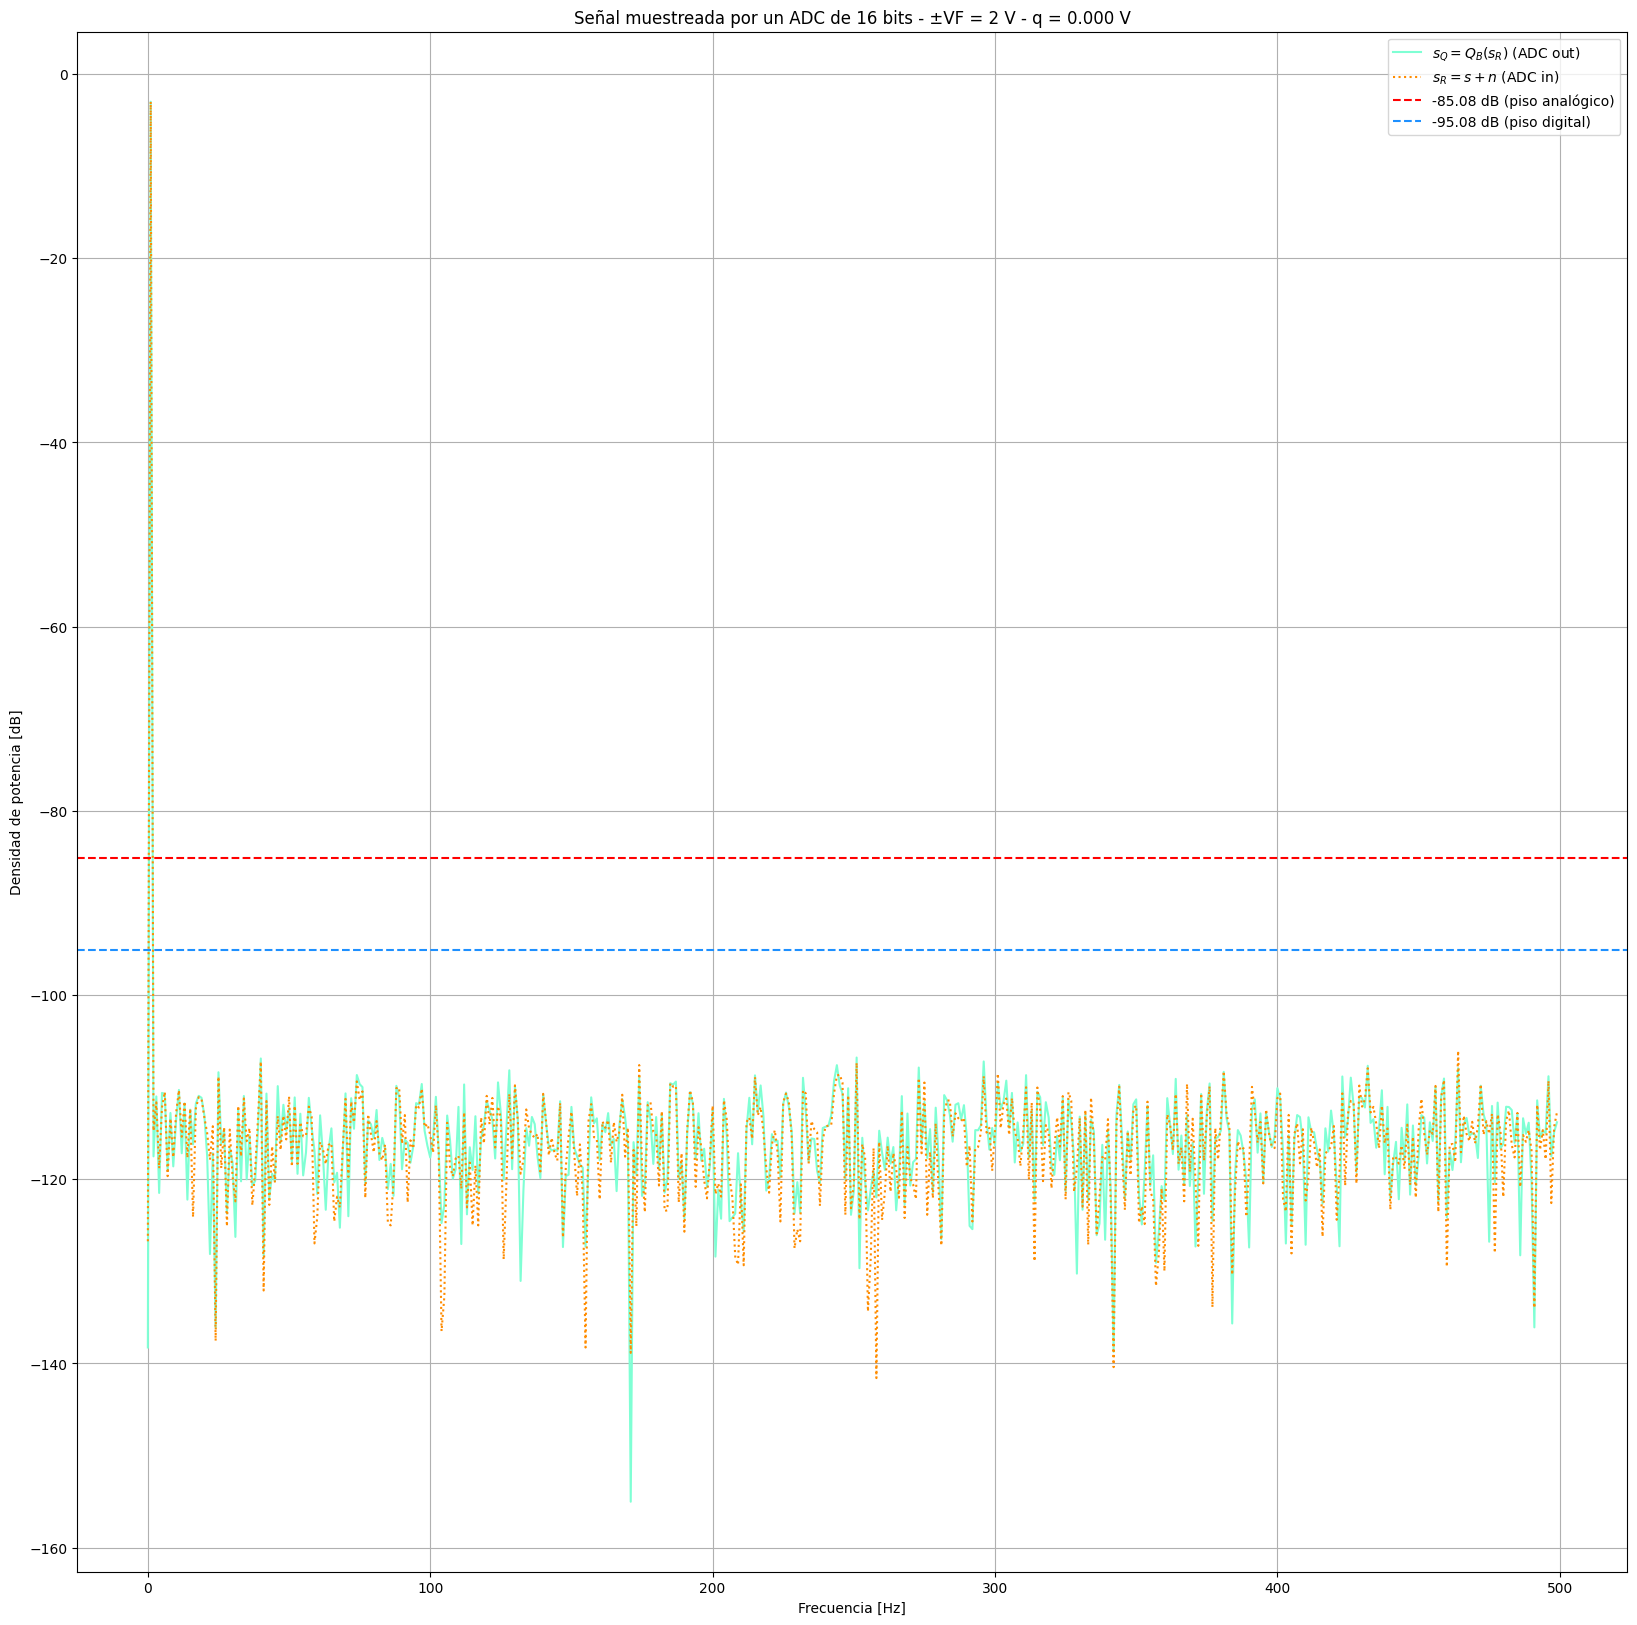

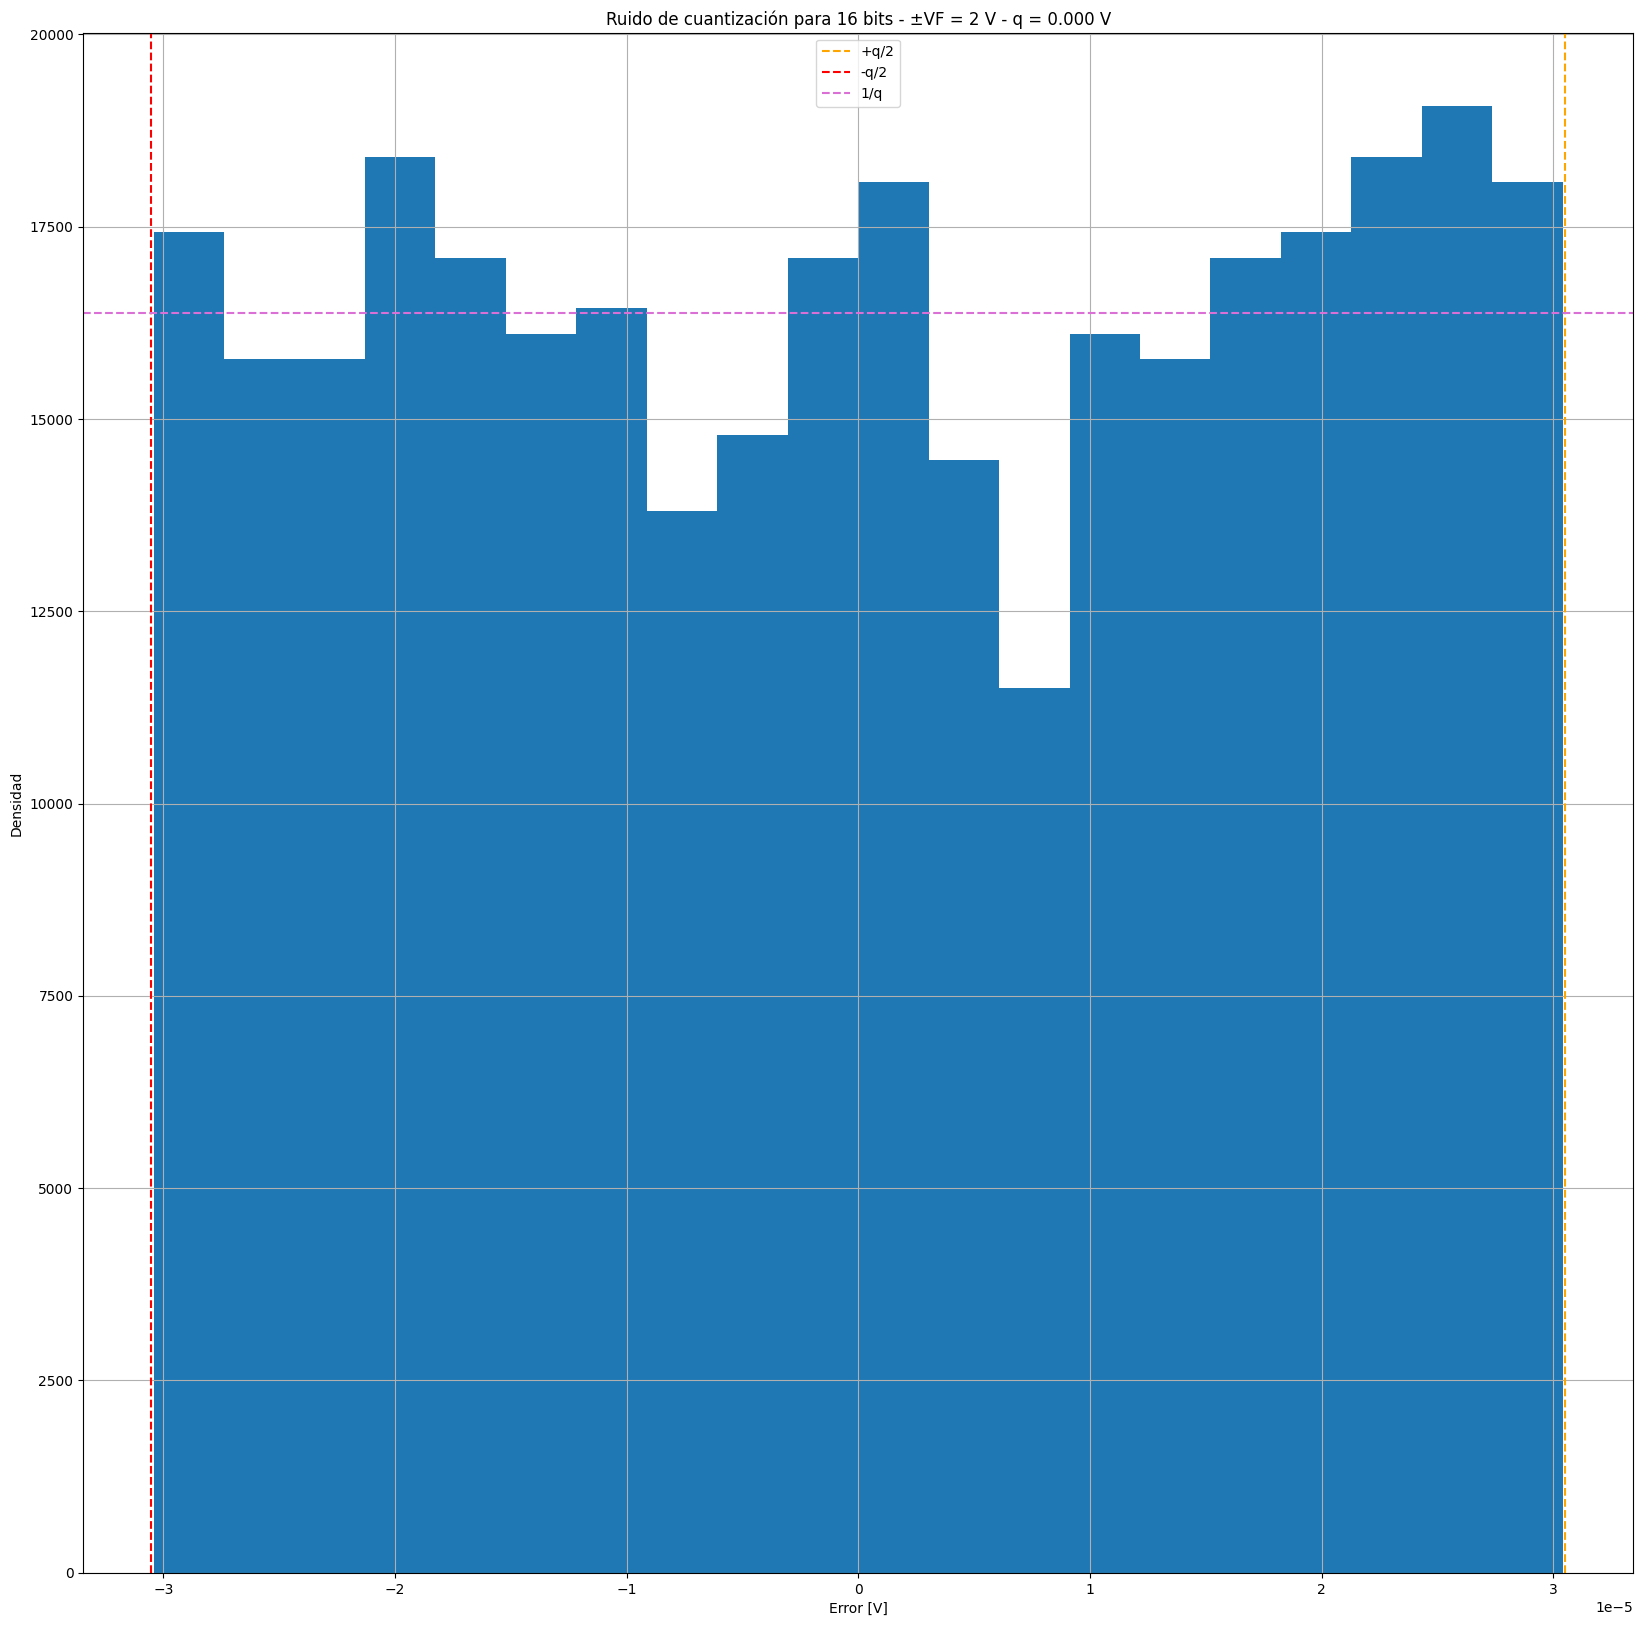

In [16]:
#%% ADC (16 bits y k = 10)
B = 16
VF = 2  # rango +-2V
q = (2*VF) / (2**B)   # paso de cuantización
Pq = (q**2) / 12      # potencia de cuantización

# Defino el ruido
kn = 10
Pn = kn * Pq
mu = 0
U_n = np.random.normal(mu, np.sqrt(Pn), n)

# Señal con ruido
sr = xx + U_n

# Cuantización (ADC)
sq = np.round(sr / q) * q

#%% FFT

N = len(xx)

# Señal pura
XX = np.fft.fft(xx)
XXmod = np.abs(XX) / N
XXmod_db = 20 * np.log10(XXmod + 1e-12)

# Señal con ruido (entrada ADC)
SR = np.fft.fft(sr)
SRmod = np.abs(SR) / N
SRmod_db = 20 * np.log10(SRmod + 1e-12)

# Señal cuantizada (salida ADC)
SQ = np.fft.fft(sq)
SQmod = np.abs(SQ) / N
SQmod_db = 20 * np.log10(SQmod + 1e-12)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, d=ts)

# Me quedo con la mitad positiva (eso es porque grafico el modulo)
mitad = N // 2
freqs = freqs[:mitad]

XXmod_db = XXmod_db[:mitad]
SRmod_db = SRmod_db[:mitad]
SQmod_db = SQmod_db[:mitad]

# Pisos teóricos
piso_analog = 10 * np.log10(Pn)
piso_digital = 10 * np.log10(Pq)

#%% Error de cuantización
e = sq - sr

#%% Graficos

# Entrada y salida del ADC
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(tt, sq, label=r'$s_Q = Q_B(s_R)$ (ADC out)')
plt.plot(tt, sr, '.', markersize=2, label=r'$s_R = s + n$ (ADC in)')
plt.plot(tt, xx, '--', label='s (analog)')

plt.title(f'Señal muestreada por un ADC de {B} bits ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')

plt.grid()
plt.legend()
plt.show()


# Espectro de la FFT
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.plot(freqs, SQmod_db, color = 'aquamarine', label=r'$s_Q = Q_B(s_R)$ (ADC out)')
# plt.plot(freqs, XXmod_db, color = 'forestgreen', label='s (analog)')
plt.plot(freqs, SRmod_db, ':', color = 'darkorange', label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analog, linestyle='--', color = 'red', label=f'{piso_analog:.2f} dB (piso analógico)')
plt.axhline(piso_digital, linestyle='--', color = 'dodgerblue', label=f'{piso_digital:.2f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VF = {VF} V - q = {q:.3f} V')

plt.grid()
plt.legend()
plt.show()


# Histograma del error de cuantizacion
plt.figure(figsize = (20, 20))  # Tamaño de la figura (ancho, alto)

plt.hist(e, bins=20, density=True)

plt.axvline(q/2, linestyle='--', color='orange', label='+q/2')
plt.axvline(-q/2, linestyle='--', color = 'red', label='-q/2')
plt.axhline(1/q, linestyle='--', color = 'orchid', label='1/q')

plt.title(f'Ruido de cuantización para {B} bits - ±VF = {VF} V - q = {q:.3f} V')
plt.xlabel('Error [V]')
plt.ylabel('Densidad')

plt.grid()
plt.legend()
plt.show()